In [4]:
from locateanything_worker import *
from PIL import Image
## init model
worker = LocateAnythingWorker("pretrained/LocateAnything-3B")

img = Image.open("giftbox_28.png").convert("RGB")


result = worker.detect(img, ["green small box", "red box", "small object", "toy car"])
print("Detection:", result["answer"])


Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/home/kewei/.cache/huggingface/modules/transformers_modules/LocateAnything_hyphen_3B/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))



Statistic Info, num_tokens=50; generate_time(s)=0.3820; tps=130.8839; forward_step=21; num_boxes=5; bps=13.0884; prefill_time=0.1142; switch_to_ar=2

Detection: <ref>green small box</ref><box><415><554><577><721></box><ref>red box</ref><box><477><244><635><506></box><ref>small object</ref><box><0><494><280><998></box><ref>toy</ref><box><670><610><735><708></box><ref>car</ref><box><0><794><30><998></box><|im_end|>


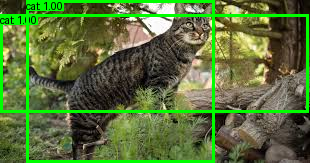

In [35]:
import re
from PIL import Image, ImageDraw, ImageFont

detection_str = result["answer"]
width, height = img.size


pattern = r"<ref>(.*?)</ref><box><(\d+)><(\d+)><(\d+)><(\d+)></box>"
matches = re.findall(pattern, detection_str)


draw = ImageDraw.Draw(img)

try:
    font = ImageFont.truetype("arial.ttf", 18)
except IOError:
    font = ImageFont.load_default()

scores = result.get("scores", [1.00] * len(matches))

for idx, (label, x1, y1, x2, y2) in enumerate(matches):
    x1 = int(float(x1) / 1000 * width)
    y1 = int(float(y1) / 1000 * height)
    x2 = int(float(x2) / 1000 * width)
    y2 = int(float(y2) / 1000 * height)
    
    score = scores[idx]
    

    display_text = f"{label}: {score:.2f}"

    draw.rectangle([x1, y1, x2, y2], outline="lime", width=3)

    try:
        text_box = draw.textbbox((x1, y1), display_text, font=font)
        draw.rectangle(text_box, fill="lime")
    except AttributeError:
        text_w, text_h = draw.textsize(display_text, font=font)
        draw.rectangle([x1, y1 - text_h, x1 + text_w, y1], fill="lime")

    draw.text((x1, y1), display_text, fill="black", font=font)

display(img)

In [8]:


img = Image.open("1.jpeg").convert("RGB")


result = worker.detect(img, ["cat"])
print("Detection:", result["answer"])



Statistic Info, num_tokens=10; generate_time(s)=0.0621; tps=161.1137; forward_step=3; num_boxes=1; bps=16.1114; prefill_time=0.0318; switch_to_ar=0

Detection: <ref>cat</ref><box><86><0><691><994></box><|im_end|>


/home/kewei/.cache/huggingface/modules/transformers_modules/LocateAnything_hyphen_3B/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))


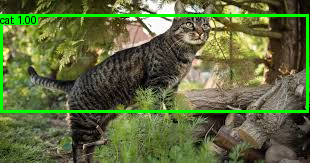

In [9]:
import re
from PIL import Image, ImageDraw, ImageFont

detection_str = result["answer"]
width, height = img.size


pattern = r"<ref>(.*?)</ref><box><(\d+)><(\d+)><(\d+)><(\d+)></box>"
matches = re.findall(pattern, detection_str)


draw = ImageDraw.Draw(img)

try:
    font = ImageFont.truetype("arial.ttf", 18)
except IOError:
    font = ImageFont.load_default()

scores = result.get("scores", [1.00] * len(matches))

for idx, (label, ymin, xmin, ymax, xmax) in enumerate(matches):
    x1 = int(float(xmin) / 1000 * width)
    y1 = int(float(ymin) / 1000 * height)
    x2 = int(float(xmax) / 1000 * width)
    y2 = int(float(ymax) / 1000 * height)
    
    score = scores[idx]
    

    display_text = f"{label}: {score:.2f}"

    draw.rectangle([x1, y1, x2, y2], outline="lime", width=3)

    try:
        text_box = draw.textbbox((x1, y1), display_text, font=font)
        draw.rectangle(text_box, fill="lime")
    except AttributeError:
        text_w, text_h = draw.textsize(display_text, font=font)
        draw.rectangle([x1, y1 - text_h, x1 + text_w, y1], fill="lime")

    draw.text((x1, y1), display_text, fill="black", font=font)

display(img)

In [2]:
import re
from PIL import Image, ImageDraw, ImageFont
from time import time 
from locateanything_worker import *
worker = LocateAnythingWorker("pretrained/LocateAnything-3B")


def single_pred_img(image_path,prompts):
    img = Image.open(image_path).convert("RGB")
    
    start = time()
    result = worker.detect(img, prompts)
    end= time()

    duration_time = end - start
    
    print(f"inference time use: {duration_time:.4f} seconds")
    print(f"FPS: {(1 / duration_time)} img/s")
    
    detection_str = result["answer"]
    width, height = img.size
    pattern = r"<ref>(.*?)</ref><box><(\d+)><(\d+)><(\d+)><(\d+)></box>"
    matches = re.findall(pattern, detection_str)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("arial.ttf", 18)
    except IOError:
        font = ImageFont.load_default()
    print()
    scores = result.get("scores", [1.00] * len(matches))
    print(scores)
    for idx, (label, x1, y1, x2, y2) in enumerate(matches):
        x1 = int(float(x1) / 1000 * width)
        y1 = int(float(y1) / 1000 * height)
        x2 = int(float(x2) / 1000 * width)
        y2 = int(float(y2) / 1000 * height)
        score = scores[idx]
        display_text = f"{label}: {score:.2f}"
        draw.rectangle([x1, y1, x2, y2], outline="lime", width=3)
        try:
            text_box = draw.textbbox((x1, y1), display_text, font=font)
            draw.rectangle(text_box, fill="lime")
        except AttributeError:
            text_w, text_h = draw.textsize(display_text, font=font)
            draw.rectangle([x1, y1 - text_h, x1 + text_w, y1], fill="lime")
    
        draw.text((x1, y1), display_text, fill="black", font=font)
    
    display(img)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/home/kewei/anaconda3/envs/locany/lib/python3.10/site-packages/transformers/models/auto/image_processing_auto.py:647: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!
flash_attn is not available for MoonViT inference; falling back to sdpa.
Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [37]:

prompts = ["cat"]
image_path = "1.jpeg"

single_pred_img(image_path,prompts)

FileNotFoundError: [Errno 2] No such file or directory: '1.jpeg'


Statistic Info, num_tokens=41; generate_time(s)=0.2468; tps=166.0968; forward_step=9; num_boxes=4; bps=16.2046; prefill_time=0.1176; switch_to_ar=0

inference time use: 0.2703 seconds
FPS: 3.6992190221681285 img/s

[1.0, 1.0, 1.0, 1.0]


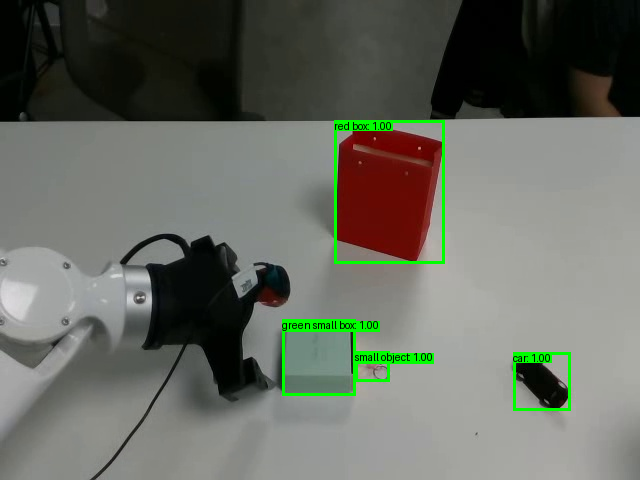

In [41]:
prompts = ["green small box", "red box", "small object", "toy car"]
image_path = "assets/test_image/giftbox_58.png"

single_pred_img(image_path,prompts)


Statistic Info, num_tokens=16; generate_time(s)=0.1650; tps=96.9836; forward_step=4; num_boxes=2; bps=12.1229; prefill_time=0.1166; switch_to_ar=0

inference time use: 0.1845 seconds
FPS: 5.42071327487383 img/s

[1.0]


/home/kewei/.cache/huggingface/modules/transformers_modules/LocateAnything_hyphen_3B/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))


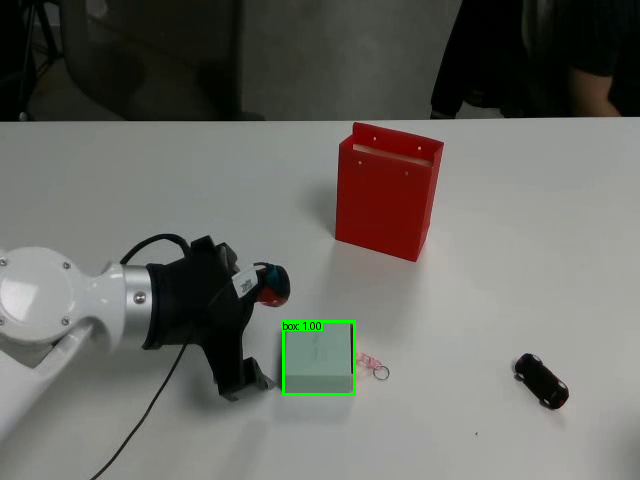

In [40]:
prompts = ["box"]
image_path = "assets/test_image/giftbox_58.png"

single_pred_img(image_path,prompts)


Statistic Info, num_tokens=10; generate_time(s)=0.0604; tps=165.5884; forward_step=3; num_boxes=1; bps=16.5588; prefill_time=0.0291; switch_to_ar=0

inference time use: 0.0715 seconds
FPS: 13.991973712741647 img/s

[1.0]


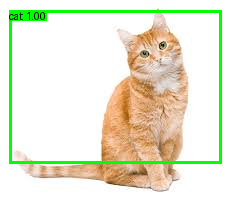


Statistic Info, num_tokens=16; generate_time(s)=0.0758; tps=211.0017; forward_step=4; num_boxes=2; bps=26.3752; prefill_time=0.0281; switch_to_ar=0

inference time use: 0.0777 seconds
FPS: 12.876153520270643 img/s

[1.0]


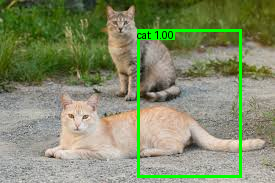

In [31]:
prompts = ["cat"]
image_path = "2.jpeg"

single_pred_img(image_path,prompts)

image_path = "3.jpeg"

single_pred_img(image_path,prompts)


Statistic Info, num_tokens=11; generate_time(s)=0.2005; tps=54.8529; forward_step=5; num_boxes=1; bps=4.9866; prefill_time=0.1421; switch_to_ar=1

inference time use: 0.2076 seconds
FPS: 4.817201929956942 img/s

[1.0]


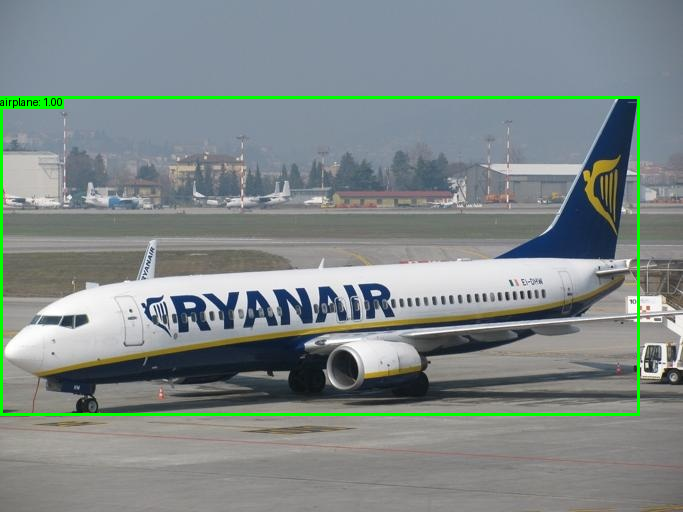

In [38]:

prompts = ["airplane"]
image_path = "assets/test_image/objects365_v1_00002727.jpg"

single_pred_img(image_path,prompts)

/home/kewei/.cache/huggingface/modules/transformers_modules/LocateAnything_hyphen_3B/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))



Statistic Info, num_tokens=51; generate_time(s)=0.5231; tps=97.4890; forward_step=15; num_boxes=6; bps=11.4693; prefill_time=0.3182; switch_to_ar=1

inference time use: 0.5367 seconds
FPS: 1.8630677802805415 img/s

[1.0, 1.0, 1.0]


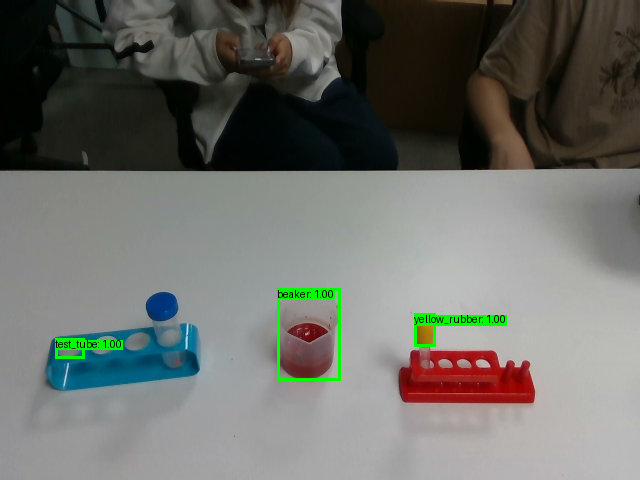

In [3]:
prompts = ["test_tube","beaker","yellow_rubber"]
image_path = "assets/test_image/beaker_9.png"

single_pred_img(image_path,prompts)

In [4]:
import re
from PIL import Image, ImageDraw, ImageFont
from time import time 
from locateanything_worker import *
worker = LocateAnythingWorker("pretrained/checkpoint-1758")


def single_pred_img(image_path,prompts):
    img = Image.open(image_path).convert("RGB")
    
    start = time()
    result = worker.detect(img, prompts)
    end= time()

    duration_time = end - start
    
    print(f"inference time use: {duration_time:.4f} seconds")
    print(f"FPS: {(1 / duration_time)} img/s")
    
    detection_str = result["answer"]
    width, height = img.size
    pattern = r"<ref>(.*?)</ref><box><(\d+)><(\d+)><(\d+)><(\d+)></box>"
    matches = re.findall(pattern, detection_str)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("arial.ttf", 18)
    except IOError:
        font = ImageFont.load_default()
    print()
    scores = result.get("scores", [1.00] * len(matches))
    print(scores)
    for idx, (label, x1, y1, x2, y2) in enumerate(matches):
        x1 = int(float(x1) / 1000 * width)
        y1 = int(float(y1) / 1000 * height)
        x2 = int(float(x2) / 1000 * width)
        y2 = int(float(y2) / 1000 * height)
        score = scores[idx]
        display_text = f"{label}: {score:.2f}"
        draw.rectangle([x1, y1, x2, y2], outline="lime", width=3)
        try:
            text_box = draw.textbbox((x1, y1), display_text, font=font)
            draw.rectangle(text_box, fill="lime")
        except AttributeError:
            text_w, text_h = draw.textsize(display_text, font=font)
            draw.rectangle([x1, y1 - text_h, x1 + text_w, y1], fill="lime")
    
        draw.text((x1, y1), display_text, fill="black", font=font)
    
    display(img)

flash_attn is not available for MoonViT inference; falling back to sdpa.
Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


trainable params: 294,624 || all params: 417,160,656 || trainable%: 0.0706
trainable params: 7,483,392 || all params: 3,407,638,528 || trainable%: 0.2196


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [5]:
prompts = ["test_tube","beaker","yellow_rubber"]
image_path = "assets/test_image/beaker_9.png"

single_pred_img(image_path,prompts)

/home/kewei/.cache/huggingface/modules/transformers_modules/checkpoint_hyphen_1758/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))



Statistic Info, num_tokens=27; generate_time(s)=0.2904; tps=92.9683; forward_step=8; num_boxes=2; bps=6.8865; prefill_time=0.1346; switch_to_ar=2

inference time use: 0.2966 seconds
FPS: 3.3718628232038736 img/s

[1.0, 1.0]


ValueError: y1 must be greater than or equal to y0